In [19]:
import numpy as np
import math
import cmath

In [20]:
f = 550
omega=2*math.pi*f
R = 0.023599
L = 1.02268
G = 0
C = 0.01142
Length = 90


z = complex(R ,omega*L/1000)
y = complex(G*1e-6 ,omega*C*1e-6)

zc = cmath.sqrt(z/y)
gamma = cmath.sqrt(z*y)
gamma_length = gamma*Length

alpha = gamma.real
beta = gamma.imag

AA= cmath.cosh(gamma_length)
BB=zc*cmath.sinh(gamma_length)
DD=AA
CC=(1/zc)*cmath.sinh(gamma_length)
Z0=zc
Y0=1/Z0
DEN= AA + BB*Y0-CC*Z0-DD
NUM = AA + BB*Y0-CC*Z0-DD
S11 = NUM/DEN
S12 = 2*(AA*DD -BB*CC)/(AA + BB * Y0 + CC*Z0 +DD)
S21 = 2/(AA + BB * Y0 + CC*Z0 +DD)
S22 = (- AA + BB*Y0 - CC*Z0 +DD)/(AA + BB * Y0 + CC*Z0 +DD)

S_matrix = np.array([[S11, S12], [S21, S22]])
print(S_matrix)

[[1.00000000e+00+0.00000000e+00j 4.84621623e-01-8.70671952e-01j]
 [4.84621623e-01-8.70671952e-01j 4.02137364e-17+2.23832250e-17j]]


System S size: 13 scalar ports (total)
Block port indices: {'Source': [0, 1], 'A': [2, 3], 'B': [4, 5, 6], 'C': [7, 8], 'D': [9, 10], 'Load': [11, 12]}

Key results (per scalar port index):
port 00: a=-0.008615-0.005195j, b=0+0j, U=-0.008615-0.005195j, |U|=0.01006
port 01: a=1+0j, b=-1.009-0.005195j, U=-0.008615-0.005195j, |U|=0.01006
port 02: a=-1.009-0.005195j, b=-0.008615-0.005195j, U=-1.017-0.01039j, |U|=1.017
port 03: a=0+0j, b=-0.521+0.8594j, U=-0.521+0.8594j, |U|=1.005
port 04: a=-0.521+0.8594j, b=0.162-0.2942j, U=-0.3591+0.5652j, |U|=0.6696
port 05: a=-0.1971+0.2711j, b=-0.162+0.2942j, U=-0.3591+0.5652j, |U|=0.6696
port 06: a=0+0j, b=-0.3591+0.5652j, U=-0.3591+0.5652j, |U|=0.6696
port 07: a=-0.162+0.2942j, b=0.0003912+0.0002938j, U=-0.1616+0.2945j, |U|=0.3359
port 08: a=0+0j, b=-0.1971+0.2711j, U=-0.1971+0.2711j, |U|=0.3351
port 09: a=-0.3591+0.5652j, b=-0.005928+0.003981j, U=-0.365+0.5692j, |U|=0.6762
port 10: a=0+0j, b=0.3722+0.5554j, U=0.3722+0.5554j, |U|=0.6685
port 11: a=0

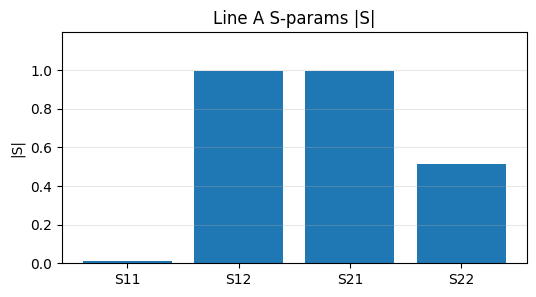

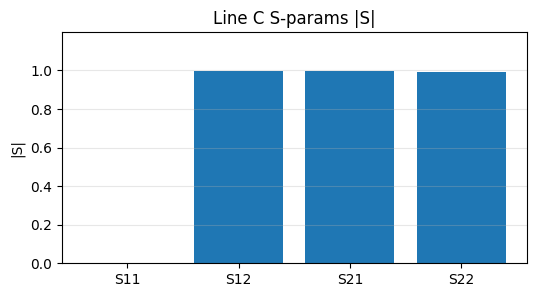

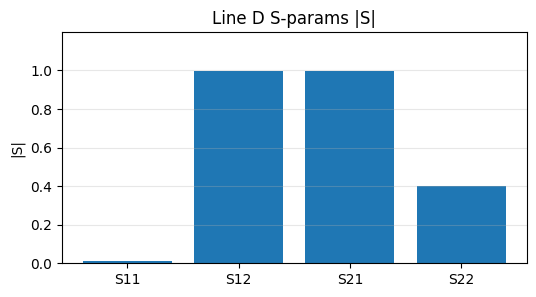

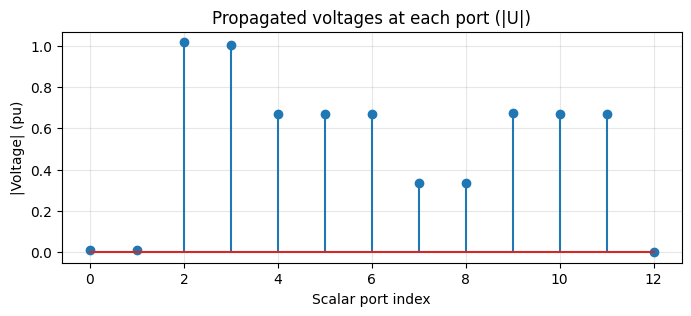

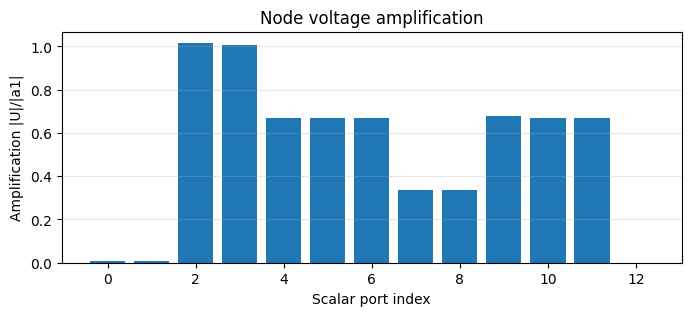

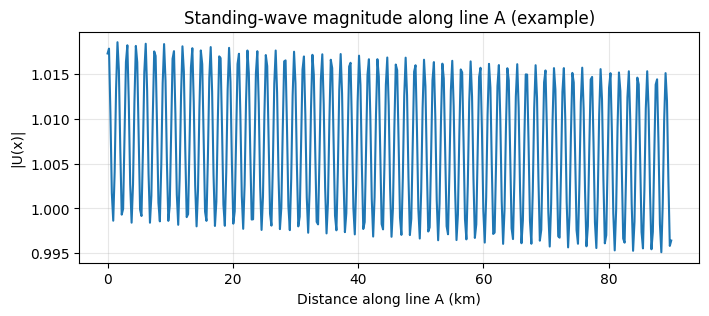


Source block S (port-to-port scattering):
[[ 0.+0.j  0.+0.j]
 [ 1.+0.j -1.+0.j]]
Source forward transmitted (= S21) magnitude: 1.0


In [ ]:
# propagation_model.py
# Requires: numpy, scipy, matplotlib
# Run: python propagation_model.py

import numpy as np
import cmath
import matplotlib.pyplot as plt
from scipy.linalg import block_diag, solve

# -----------------------
# Helper functions
# -----------------------
j = 1j

def omega_from_f(f):
    return 2.0 * np.pi * f

def line_secondary_constants(Rp, Lp, Gp, Cp, omega):
    
    z = Rp + j * omega * Lp
    y = Gp + j * omega * Cp
    gamma = cmath.sqrt(z * y)      # complex propagation constant (alpha + j beta)
    Z0 = cmath.sqrt(z / y)         # characteristic impedance
    return z, y, gamma, Z0

def abcd_from_gamma_Z0(gamma, Z0, length):
  
    gl = gamma * length
    A = cmath.cosh(gl)
    B = Z0 * cmath.sinh(gl)
    C = (1.0 / Z0) * cmath.sinh(gl)
    D = A
    return A, B, C, D

def s_from_abcd(A,B,C,D,Z0_ref):
    """Convert ABCD -> S using eqs (4.40)-(4.43) (see thesis). Y0 = 1/Z0_ref."""
    Y0 = 1.0 / Z0_ref
    denom = A + B * Y0 + C * Z0_ref + D
    S11 = (A + B * Y0 - C * Z0_ref - D) / denom
    S12 = 2.0 * (A * D - B * C) / denom
    S21 = 2.0 / denom
    S22 = (-A + B * Y0 - C * Z0_ref + D * (-1)) / denom  # same as formula rearranged
    # (Note: implemented to match algebraic form in the thesis eqns)
    return S11, S12, S21, S22

# voltage at a port (voltage wave definition): U_port = a + b
# incident a and reflected b are complex phasors (voltage waves) per port.

# -----------------------
# Example network definition (generic Fig.4.11 -> Fig.4.13)
# We'll create a small demo network: Source -- A -- B(3-port) -- C (open) and D (load)
# Node/port numbering follows the thesis example mapping: 13 total scalar ports in the example.
# For reproducible work change the lines/blocks to your actual network and R/L/G/C tables.
# -----------------------

f_hz = 550.0
omega = omega_from_f(f_hz)

# Example: define line sections (these are per-section aggregated parameters)
# For a precise reproduction, use distributed R/L/G/C per meter. Here we assume
# "Rp, Lp, Gp, Cp" are per meter values. Replace with accurate values (Ω/m, H/m, S/m, F/m).
# In the thesis examples they compute ABCD from distributed parameters and length (see E.11).
# Use consistent units.
lines = {
    # block name : (R_per_m, L_per_m, G_per_m, C_per_m, length_m, Z0_ref_for_conversion)
    'A': (0.023599/1000.0, 1.02268e-3/1.0, 0.0, 11.42e-9, 90e3, 295.78),   # example scaled
    'C': (0.023599/1000.0, 1.02268e-3/1.0, 0.0, 11.42e-9, 50e3, 295.78),
    'D': (0.023599/1000.0, 1.02268e-3/1.0, 0.0, 11.42e-9, 40e3, 295.78),
    # block B will be modelled as a 3-port junction (we'll create an S-block)
}

# For simplicity, define S-blocks for A, C, D as two-port networks computed below.
block_names = ['Source','A','B','C','D','Load']

# -----------------------
# Build component S-blocks
# -----------------------
S_blocks = []   # will contain S-block matrices (square) in port-order
block_port_counts = {}  # number of scalar ports per block (2 for two-port, 3 for three-port source etc.)

# 1) Source block: two-port per thesis model (eq 4.44): b = [[0,0],[1,Γs]] * [a]
# We'll implement a general S for a Thevenin-like source. Port ordering: [port_src_side, port_to_grid]
Gamma_s = -1.0 + 0j   # example reflection at source terminal (choose per study), thesis used -1 in examples.
a1_mag = 1.0          # source incident a1 amplitude (per-unit)
# Source S matrix (2x2) per thesis (eq 4.44) - they model as:
S_source = np.array([[0+0j, 0+0j],
                     [1+0j, Gamma_s+0j]])
S_blocks.append(S_source)
block_port_counts['Source'] = 2

# 2) Transmission line A: compute ABCD from distributed RLGC and convert to S (2-port)
def make_twoport_from_line(params):
    Rpm, Lpm, Gpm, Cpm, L_m, Z0_ref = params
    z, y, gamma, Z0 = line_secondary_constants(Rpm, Lpm, Gpm, Cpm, omega)
    A,B,C_,D = abcd_from_gamma_Z0(gamma, Z0, L_m)
    S11,S12,S21,S22 = s_from_abcd(A,B,C_,D, Z0_ref)
    Sblock = np.array([[S11, S12],
                       [S21, S22]], dtype=complex)
    meta = {'gamma': gamma, 'Z0': Z0, 'A':A,'B':B,'C':C_,'D':D}
    return Sblock, meta

S_A, meta_A = make_twoport_from_line(lines['A'])
S_blocks.append(S_A); block_port_counts['A']=2

# 3) Block B: 3-port junction. For simplicity create ideal three-port junction that splits with reflections.
# In practice create measured/derived S from network model or from the thesis's 3-port modelling approach.
# We'll build a simple symmetric 3-port passive junction S which is lossless reciprocal (example).
S_B = np.array([
    [ -0.5+0j,  0.5+0j,  0.5+0j],
    [  0.5+0j, -0.5+0j,  0.5+0j],
    [  0.5+0j,  0.5+0j, -0.5+0j],
], dtype=complex)
S_blocks.append(S_B); block_port_counts['B']=3

# 4) Transmission line C and D two-ports
S_C, meta_C = make_twoport_from_line(lines['C'])
S_blocks.append(S_C); block_port_counts['C']=2

S_D, meta_D = make_twoport_from_line(lines['D'])
S_blocks.append(S_D); block_port_counts['D']=2

# 5) Load block: model a terminating 2-port (e.g., open or load with reflection coefficient Gamma_load)
Gamma_load = 0.0 + 0j  # matched load example (no reflection)
S_load = np.array([[0+0j, 0+0j],
                   [0+0j, Gamma_load+0j]])
S_blocks.append(S_load); block_port_counts['Load']=2

# -----------------------
# Assemble full system S (block-diagonal)
# -----------------------
S_system = block_diag(*S_blocks)                    # big NxN scattering matrix (N = total scalar ports)
N_ports = S_system.shape[0]
print(f"System S size: {N_ports} scalar ports (total)")

# -----------------------
# Example connection matrix C (maps outputs b to inputs a)
# The connection matrix is binary (0/1) mapping the b_i outputs to a_j inputs.
# The example mapping follows the thesis Fig.4.13 ordering of ports (example only).
# We must define the mapping of scalar ports indices. We'll create a small demo mapping.
# -----------------------
# Determine scalar port indices for each block in the same order as block_diag assembly:
port_index = 0
block_port_index = {}
for name in block_names:
    cnt = block_port_counts[name]
    block_port_index[name] = list(range(port_index, port_index + cnt))
    port_index += cnt

print("Block port indices:", block_port_index)

# Build C as zeros then fill unity connections where ports are connected physically
C = np.zeros((N_ports, N_ports), dtype=complex)

# Example connections (mimicking Fig.4.13):
# Source port 2 (output) -> A port1 (input)
C[ block_port_index['A'][0], block_port_index['Source'][1] ] = 1.0
# A port2 (output) -> B port1 (input)
C[ block_port_index['B'][0], block_port_index['A'][1] ] = 1.0
# B outputs to C and D
C[ block_port_index['C'][0], block_port_index['B'][1] ] = 1.0
C[ block_port_index['D'][0], block_port_index['B'][2] ] = 1.0
# And feedback connections back into upstream blocks per Fig.4.13 (bX -> aY)
# output of C (port2) back to B (as one of its inputs)
C[ block_port_index['B'][1], block_port_index['C'][1] ] = 1.0
# output of D (port2) -> load (port1)
C[ block_port_index['Load'][0], block_port_index['D'][1] ] = 1.0
# output of load back to D input (if reflection)
C[ block_port_index['D'][1], block_port_index['Load'][1] ] = 1.0
# output of A to source input (reflected to source)
C[ block_port_index['Source'][0], block_port_index['A'][0] ] = 1.0

# (NOTE) The above mapping is a small demo. For your full model build C from the actual network port map (Fig.4.13).
# See thesis Section 5.2 for construction of C and Section 5.3 for S block ordering. :contentReference[oaicite:2]{index=2}

# -----------------------
# Solve for waves:
# We'll follow (I - C S) a = source_vector  (see thesis eqns leading to M := I - C S)
# Choose a source excitation vector 'src' that sets incident wave a on source port(s).
# -----------------------
I = np.eye(N_ports, dtype=complex)
CS = C.dot(S_system)
M = I - CS

# Source incident excitation: set the 'a' on source port 0 of Source block (port index)
src_vec = np.zeros(N_ports, dtype=complex)
# In thesis they often set a1 = 1 (per-unit) to evaluate propagation per source unit. We'll set source port index 0 = a1
src_vec[ block_port_index['Source'][0] ] = 0.0+0j   # a1 in Thevenin side (often 0 for the source two-port formalism)
# we instead set the incident entering the source block's other port (port 1) as the "drive" used in thesis
src_vec[ block_port_index['Source'][1] ] = a1_mag + 0j

# Solve linear system for 'a'. Note M might be singular for pathological cases; use solve from scipy.linalg.
try:
    a = solve(M, src_vec)
except Exception as exc:
    print("Direct solve failed (M singular?). Trying least-squares fallback.")
    a, *_ = np.linalg.lstsq(M, src_vec, rcond=None)

# Now compute b = S_system * a
b = S_system.dot(a)

# Voltages at scalar ports:
U_ports = a + b      # definition: U = a + b (voltage wave = incident + reflected)
U_abs = np.abs(U_ports)

# Print key results
print("\nKey results (per scalar port index):")
for idx in range(N_ports):
    print(f"port {idx:02d}: a={a[idx]:.4g}, b={b[idx]:.4g}, U={U_ports[idx]:.4g}, |U|={U_abs[idx]:.4g}")

# -----------------------
# Visualizations requested:
# 1) Line-section S-parameters (magnitude/angle)
# We'll plot S magnitude for each 2-port line block (A, C, D) we computed.
# -----------------------
def plot_s_block(Sblock, title):
    plt.figure(figsize=(6,3))
    S11,S12,S21,S22 = Sblock.flatten()
    mags = [abs(S11), abs(S12), abs(S21), abs(S22)]
    names = ['S11','S12','S21','S22']
    plt.bar(names, mags)
    plt.title(title + " |S|")
    plt.ylim(0, max(1.0, max(mags)*1.2))
    plt.ylabel('|S|')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_s_block(S_A, "Line A S-params")
plot_s_block(S_C, "Line C S-params")
plot_s_block(S_D, "Line D S-params")

# 2) Propagated voltage patterns: scatter of |U| across scalar ports
plt.figure(figsize=(8,3))
plt.stem(range(N_ports), U_abs)
plt.xlabel('Scalar port index')
plt.ylabel('|Voltage| (pu)')
plt.title('Propagated voltages at each port (|U|)')
plt.grid(alpha=0.3)
plt.show()

# 3) Voltage amplification at nodes:
# pick a reference: source port magnitude a1_mag (we used =1). Amplification = |U_node| / |a1|
amp = U_abs / (abs(a1_mag) + 1e-15)
plt.figure(figsize=(8,3))
plt.bar(range(N_ports), amp)
plt.xlabel('Scalar port index')
plt.ylabel('Amplification |U|/|a1|')
plt.title('Node voltage amplification')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4) Standing wave pattern along a line: choose line A (port index mapping)
# We use U(x) = a_port * exp(-gamma*x) + b_port * exp(gamma*x) as a consistent traveling wave representation
# (equivalent to the telegrapher solution expressed in thesis eq 4.10-4.11). See thesis telegraph eqns. :contentReference[oaicite:3]{index=3}
gamma_A = meta_A['gamma']
Z0_A = meta_A['Z0']
# port 0 of A is series node 0 (input), port1 is output; incident at port0 = a[index]
a_port_idx = block_port_index['A'][0]   # input port scalar index
b_port_idx = block_port_index['A'][0]   # note: reflection at same port used to build local wave (simplified)
Uplus = a[a_port_idx]
Uminus = b[a_port_idx]
xs = np.linspace(0, lines['A'][4], 400)
Uxs = [Uplus * cmath.exp(-gamma_A * x) + Uminus * cmath.exp(gamma_A * x) for x in xs]
Uxs_abs = np.array([abs(u) for u in Uxs])

plt.figure(figsize=(8,3))
plt.plot(xs/1000.0, Uxs_abs)
plt.xlabel('Distance along line A (km)')
plt.ylabel('|U(x)|')
plt.title('Standing-wave magnitude along line A (example)')
plt.grid(alpha=0.3)
plt.show()

# 5) Source propagation characteristics: show how much of source incident leaves the source ports (S-matrix rows)
s_row = S_source[1,:]
print("\nSource block S (port-to-port scattering):")
print(S_source)
print("Source forward transmitted (= S21) magnitude:", abs(S_source[1,0]))

# -----------------------
# End of script
# -----------------------


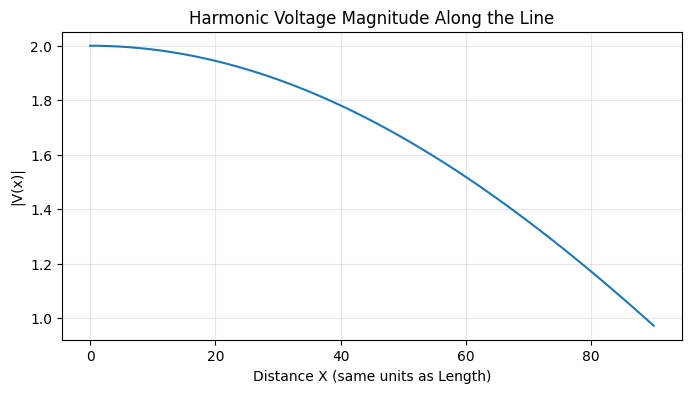

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
# Propagation constant gamma = α + jβ (per unit length)
# Replace with your own if needed
gamma = 3.942978e-05 + 1j * 1.180995e-02   # per-unit length
Length = 90.0                              # total line length (same units as X)

# --- Computation ---
X = np.arange(0, Length + 1, 1)            # X = 0:1:Length
beta = np.imag(gamma)                      # phase constant
Vx = np.abs(1 + np.exp(-2j * beta * X))    # |1 + e^{-j 2βX}|

# --- Plot ---
plt.figure(figsize=(8, 4))
plt.plot(X, Vx)
plt.xlabel('Distance X (same units as Length)')
plt.ylabel('|V(x)|')
plt.title('Harmonic Voltage Magnitude Along the Line')
plt.grid(True, alpha=0.3)
plt.show()
